<a href="https://colab.research.google.com/github/mythien107/busad878/blob/main/Week_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Exploration

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/mythien107/busad878/refs/heads/main/earbuds_sales_history.csv"
df = pd.read_csv(url)
df['week_ending'] = pd.to_datetime(df['week_ending'])
print(df.shape)
df.head(10)

(156, 8)


,week_ending,units_sold,revenue,avg_price,promotion_flag,promotion_type,competitor_launch,season
0,2024-01-07,14954,1804947.80,120.70,0,none,0,Q1
1,2024-01-14,15303,1851663.00,121.00,0,none,0,Q1
2,2024-01-21,14496,1698206.40,117.15,0,none,0,Q1
3,2024-01-28,15730,1930228.30,122.71,0,none,0,Q1
4,2024-02-04,18184,2186807.84,120.26,0,none,0,Q1
5,2024-02-11,22025,2504022.25,113.69,1,bundle,0,Q1
6,2024-02-18,18669,2197714.68,117.72,0,none,0,Q1
7,2024-02-25,17628,2118709.32,120.19,0,none,0,Q1
8,2024-03-03,16272,1912448.16,117.53,0,none,0,Q1
9,2024-03-10,14268,1666074.36,116.77,0,none,1,Q1


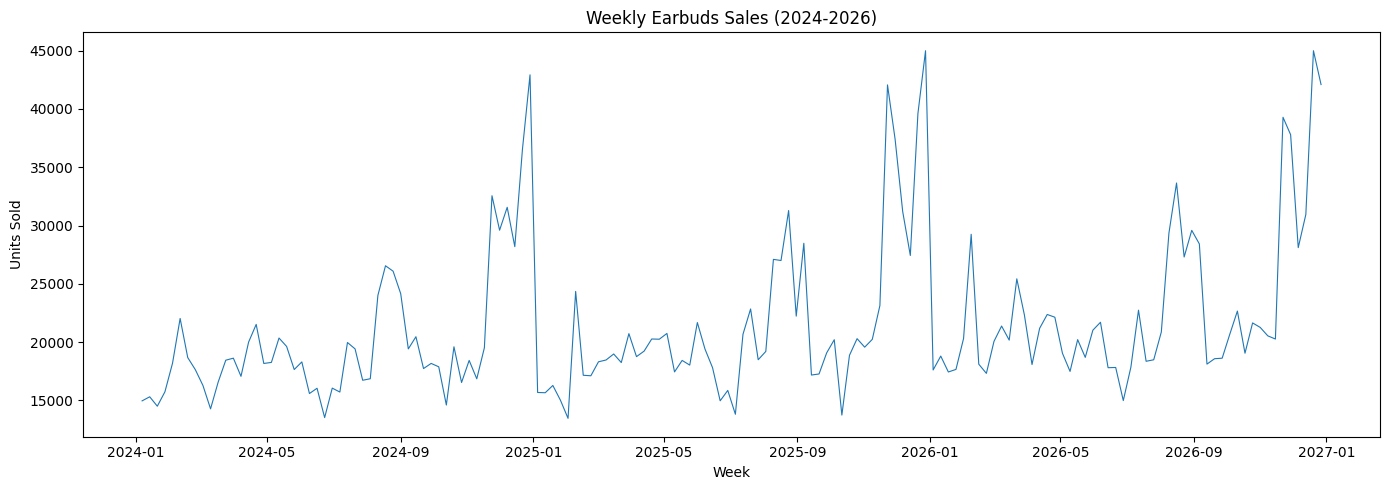

In [2]:
plt.figure(figsize=(14, 5))
plt.plot(df['week_ending'], df['units_sold'], linewidth=0.8)
plt.title('Weekly Earbuds Sales (2024-2026)')
plt.ylabel('Units Sold')
plt.xlabel('Week')
plt.tight_layout()
plt.show()

In [3]:
# Seasonal averages
seasonal = df.groupby('season')['units_sold'].mean()
print('Average units by season:')
print(seasonal)

# Promotion impact
promo = df.groupby('promotion_flag')['units_sold'].mean()
print('\nAvg units - No promo:', int(promo[0]))
print('Avg units - Promo:   ', int(promo[1]))
print(f'Promo lift: {(promo[1]/promo[0]-1)*100:.1f}%')

Average units by season:
season
Q1    18367.179487
Q2    18649.769231
Q3    21837.307692
Q4    26992.923077
Name: units_sold, dtype: float64

Avg units - No promo: 18987
Avg units - Promo:    29418
Promo lift: 54.9%


In [4]:
comp = df.groupby('competitor_launch')['units_sold'].mean()
print(f'Avg units - No competitor launch: {int(comp[0])}')
print(f'Avg units - Competitor launch:    {int(comp[1])}')
print(f'Competitor impact: {(comp[1]/comp[0]-1)*100:.1f}%')

Avg units - No competitor launch: 21840
Avg units - Competitor launch:    16921
Competitor impact: -22.5%


# Building the Quantitative Baseline

In [5]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Fit Holt-Winters with multiplicative seasonality
model = ExponentialSmoothing(
    df['units_sold'],
    trend='add',
    seasonal='mul',
    seasonal_periods=52  # weekly seasonality
).fit()

# Forecast next 39 weeks (through Q3 2027)
forecast = model.forecast(39)
print(f'Q3 2027 forecast (weeks 27-39 of forecast):')
q3_forecast = forecast.iloc[26:39]
print(f'  Weekly avg: {int(q3_forecast.mean()):,} units')
print(f'  Q3 total:   {int(q3_forecast.sum()):,} units')

q3_2027_avg = q3_forecast.mean()

# Q3 2026 actuals for comparison
q3_2026 = df[df['week_ending'].between('2026-07-01', '2026-09-30')]['units_sold']
q3_2026_avg = q3_2026.mean()

growth = (q3_2027_avg - q3_2026_avg) / q3_2026_avg
print(f"Q3 2026 actual avg:   {int(q3_2026_avg):,} units")
print(f"Q3 2027 forecast avg: {int(q3_2027_avg):,} units")
print(f"YoY growth:           {growth:.1%}")

Q3 2027 forecast (weeks 27-39 of forecast):
  Weekly avg: 23,408 units
  Q3 total:   304,306 units
Q3 2026 actual avg:   23,221 units
Q3 2027 forecast avg: 23,408 units
YoY growth:           0.8%


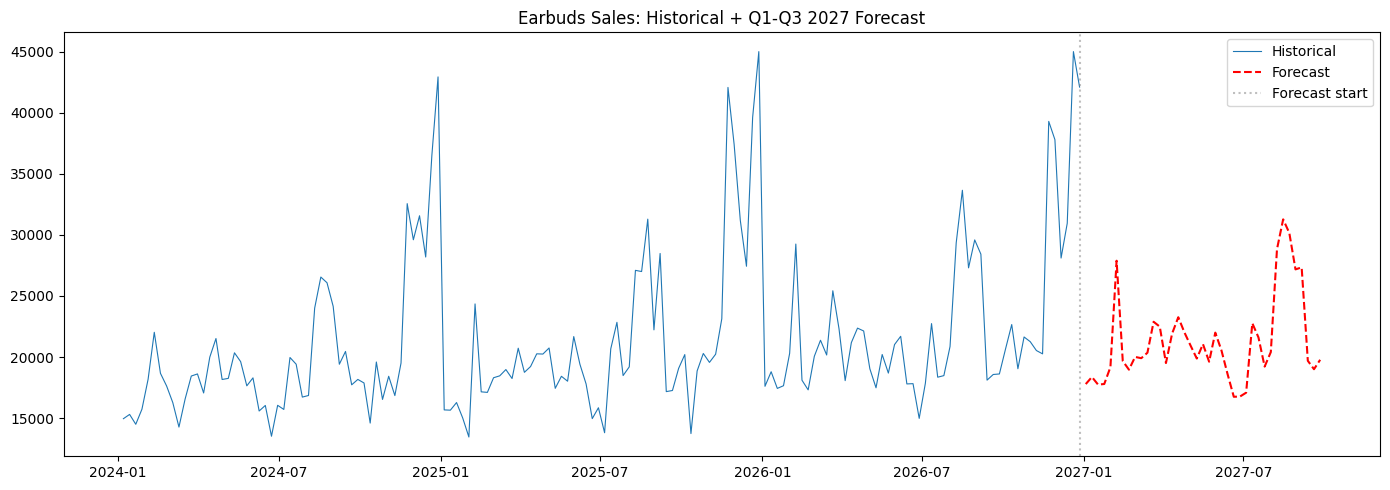

In [6]:
plt.figure(figsize=(14, 5))
plt.plot(df['week_ending'], df['units_sold'], label='Historical', linewidth=0.8)

import numpy as np
future_dates = pd.date_range(
    start=df['week_ending'].iloc[-1] + pd.Timedelta(weeks=1),
    periods=39, freq='W'
)
plt.plot(future_dates, forecast.values, label='Forecast',
         color='red', linewidth=1.5, linestyle='--')
plt.axvline(x=df['week_ending'].iloc[-1], color='gray',
            linestyle=':', alpha=0.5, label='Forecast start')
plt.title('Earbuds Sales: Historical + Q1-Q3 2027 Forecast')
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
q3_baseline = int(q3_forecast.mean())
print(f'Quantitative baseline (weekly avg): {q3_baseline:,} units')

Quantitative baseline (weekly avg): 23,408 units


In [8]:
# Apply qualitative adjustments
# These are YOUR judgment calls based on LLM intelligence
adjustments = {
    'Apple Sept launch impact': -0.08,    # ~8% hit for 3-4 weeks
    'Economic headwinds':       -0.03,    # Consumer spending softening
    'AI features tailwind':     +0.05,    # New features driving upgrades
    'Summer seasonality':       +0.00,    # Already in the model
}

total_adjustment = sum(adjustments.values())
adjusted_forecast = int(q3_baseline * (1 + total_adjustment))

print(f'\nQualitative adjustments:')
for factor, adj in adjustments.items():
    print(f'  {factor}: {"+" if adj >= 0 else ""}{adj*100:.0f}%')
print(f'\nTotal adjustment: {total_adjustment*100:+.0f}%')
print(f'Adjusted forecast (weekly avg): {adjusted_forecast:,} units')


Qualitative adjustments:
  Apple Sept launch impact: -8%
  Economic headwinds: -3%
  AI features tailwind: +5%
  Summer seasonality: +0%

Total adjustment: -6%
Adjusted forecast (weekly avg): 22,003 units


# Scenario-weighted forecast

In [9]:
# Scenario-weighted expected demand
scenarios = {
    'Bear':  {'index': 88,  'prob': 0.25}, # index is the demand multiplier expressed as % of your baseline (index = 100 means demand equals baseline)
    'Base':  {'index': 103, 'prob': 0.55},
    'Bull':  {'index': 115, 'prob': 0.20},
}

print('Scenario-Weighted Forecast:')
print('-' * 45)
weighted_index = 0
for name, s in scenarios.items():
    weighted = s['index'] * s['prob']
    weighted_index += weighted
    weekly = int(q3_baseline * s['index'] / 100)
    print(f"  {name:5s}: Index {s['index']:3d} x {s['prob']:.0%} prob "
          f"= {weekly:>6,} units/wk")

expected_weekly = int(q3_baseline * weighted_index / 100)
print(f'\n  Expected value: {expected_weekly:,} units/week')
print(f'  Q3 total (13 weeks): {expected_weekly * 13:,} units')

Scenario-Weighted Forecast:
---------------------------------------------
  Bear : Index  88 x 25% prob = 20,599 units/wk
  Base : Index 103 x 55% prob = 24,110 units/wk
  Bull : Index 115 x 20% prob = 26,919 units/wk

  Expected value: 23,794 units/week
  Q3 total (13 weeks): 309,322 units
